In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/bone_marrow_processed.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 441 ms, sys: 1.16 s, total: 1.6 s
Wall time: 12.3 s


AnnData object with n_obs × n_vars = 5608 × 22954
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'CD34_avg', 'CD164_avg', 'PROM1_avg', 'CD48_avg', 'FLT3_avg', 'MPO_avg', 'IRF8_avg', 'CD79A_avg', 'GATA1_avg', 'CD34pos_CD38neg_B0251_HTO_1', 'CD34pos_CD38pos_B0252_HTO_2', 'HTO_pred', 'HTO_pred_label', 'cluster_preds', 'CD164_mean', 'CD34_mean', 'CD38_mean', 'THY1_mean', 'PTPRC_mean', 'MME_mean', 'CD7_mean', 'FLT3_mean', 'PLEK_mean', 'BST2_mean', 'CD37_mean', 'KIT_mean', 'ICAM3_mean', 'CD44_mean', 'EVI2B_mean', 'CD63_mean', 'ITGA2B_mean', 'CSF2RB_mean', 'PROM1_mean', 'ATP1B3_mean',

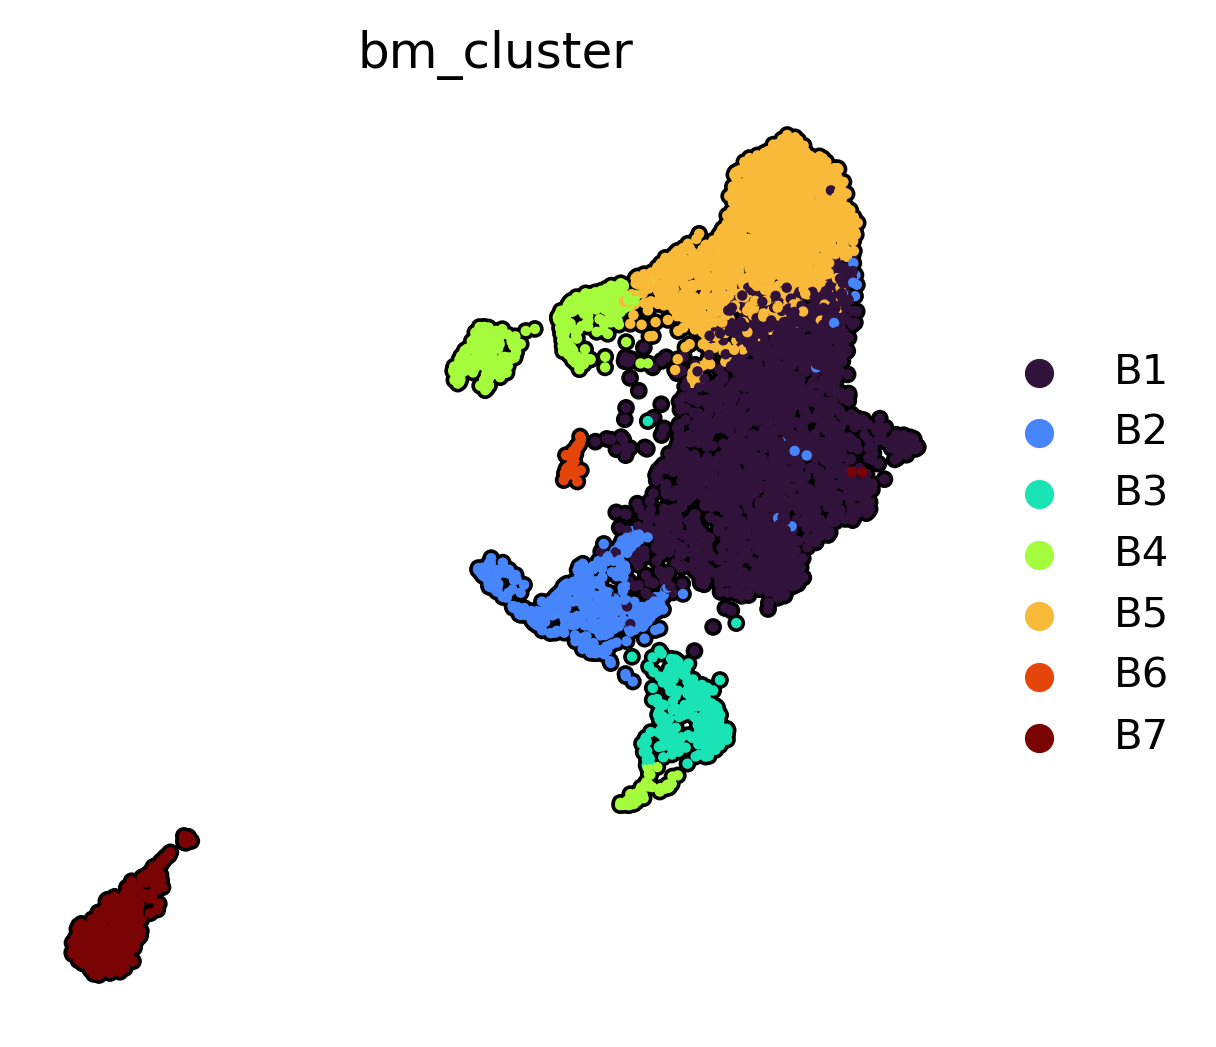

In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color='bm_cluster',
    palette='turbo',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# Hashing

In [4]:
fpath = "/scratch/indikar_root/indikar1/shared_data/bone_marrow_tsb_hashes/feature_barcodes/fbc_map.csv"
df = pd.read_csv(fpath)

df['cell_barcode'] = df['cell_barcode'] + "-1"
df = df.drop(columns='pred')
df = pd.melt(df, id_vars='cell_barcode')

df["variable"] = df["variable"].str.replace(r"^chunk_\d+_", "", regex=True)
print(list(df['variable'].unique()))

print(f"Total cells: {df['cell_barcode'].nunique()}")
print(f"Total reads: {df['value'].sum()}")
print(f"Mean reads/cell: {df['value'].sum() / df['cell_barcode'].nunique()}")

print(f"\n---- Total Reads by Hash Code  ----")
gx = df.groupby('variable')['value'].sum()
print(gx.to_string())

# sum over all chunks (by cell id)
df = df.groupby(['cell_barcode', 'variable'])['value'].sum().reset_index()
df = pd.pivot_table(df, index='cell_barcode', columns='variable', values='value', fill_value=0.0)

df = df.reindex(adata.obs_names) 
df['hash_prediction'] = df.idxmax(axis=1)

print(f"\n---- Predictions by Hash Code  ----")
print(df['hash_prediction'].value_counts().to_string())

print()
print(df.head().to_string())

['CD34p_CD38n', 'CD34p_CD38p']
Total cells: 6291
Total reads: 675450.0
Mean reads/cell: 107.36766809728184

---- Total Reads by Hash Code  ----
variable
CD34p_CD38n    579999.0
CD34p_CD38p     95451.0


/tmp/ipykernel_2124048/2740956043.py:24: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['hash_prediction'] = df.idxmax(axis=1)



---- Predictions by Hash Code  ----
hash_prediction
CD34p_CD38n    5009
CD34p_CD38p     590

variable            CD34p_CD38n  CD34p_CD38p hash_prediction
AAACCAAAGGCGATCT-1         53.0          3.0     CD34p_CD38n
AAACCAAAGGTGAACG-1         35.0          4.0     CD34p_CD38n
AAACCATTCCCTGTCA-1         72.0          3.0     CD34p_CD38n
AAACCATTCCGCGATG-1         50.0          7.0     CD34p_CD38n
AAACCATTCCTGTCGC-1         37.0          4.0     CD34p_CD38n


In [5]:
adata.obs = adata.obs.join(df)    
adata.obs.head()

,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,ITGB2_mean,CD53_mean,CD48_mean,LAIR1_mean,CD74_mean,SELL_mean,cell_labels,CD34p_CD38n,CD34p_CD38p,hash_prediction
AAACCAAAGGCGATCT-1,bone_marrow,7035,8.858795,44635.0,10.706296,34.950151,49.842052,57.302565,66.010978,1521.0,...,0.226036,0.696542,0.286691,0.512722,2.758574,1.337802,MPP,53.0,3.0,CD34p_CD38n
AAACCAAAGGTGAACG-1,bone_marrow,4440,8.398635,21652.0,9.982900,37.091262,51.533346,59.763532,69.517827,639.0,...,0.092191,0.317394,0.006043,0.125927,1.277790,0.186091,MEG/ERY,35.0,4.0,CD34p_CD38n
AAACCATTCCCTGTCA-1,bone_marrow,6370,8.759512,40379.0,10.606090,33.547141,47.425642,56.833998,66.601451,1230.0,...,0.255319,0.621765,0.284677,0.454510,2.544269,1.247767,CMP,72.0,3.0,CD34p_CD38n
AAACCATTCCGCGATG-1,bone_marrow,3872,8.261785,15760.0,9.665294,37.912437,51.979695,59.904822,69.302030,545.0,...,0.101116,0.598736,0.092357,0.436981,2.921885,1.327408,HSC,50.0,7.0,CD34p_CD38n
AAACCATTCCTGTCGC-1,bone_marrow,4817,8.480114,19367.0,9.871378,30.897919,43.754841,52.253834,62.621986,624.0,...,0.226036,0.696542,0.286691,0.512722,2.758574,1.337802,MPP,37.0,4.0,CD34p_CD38n


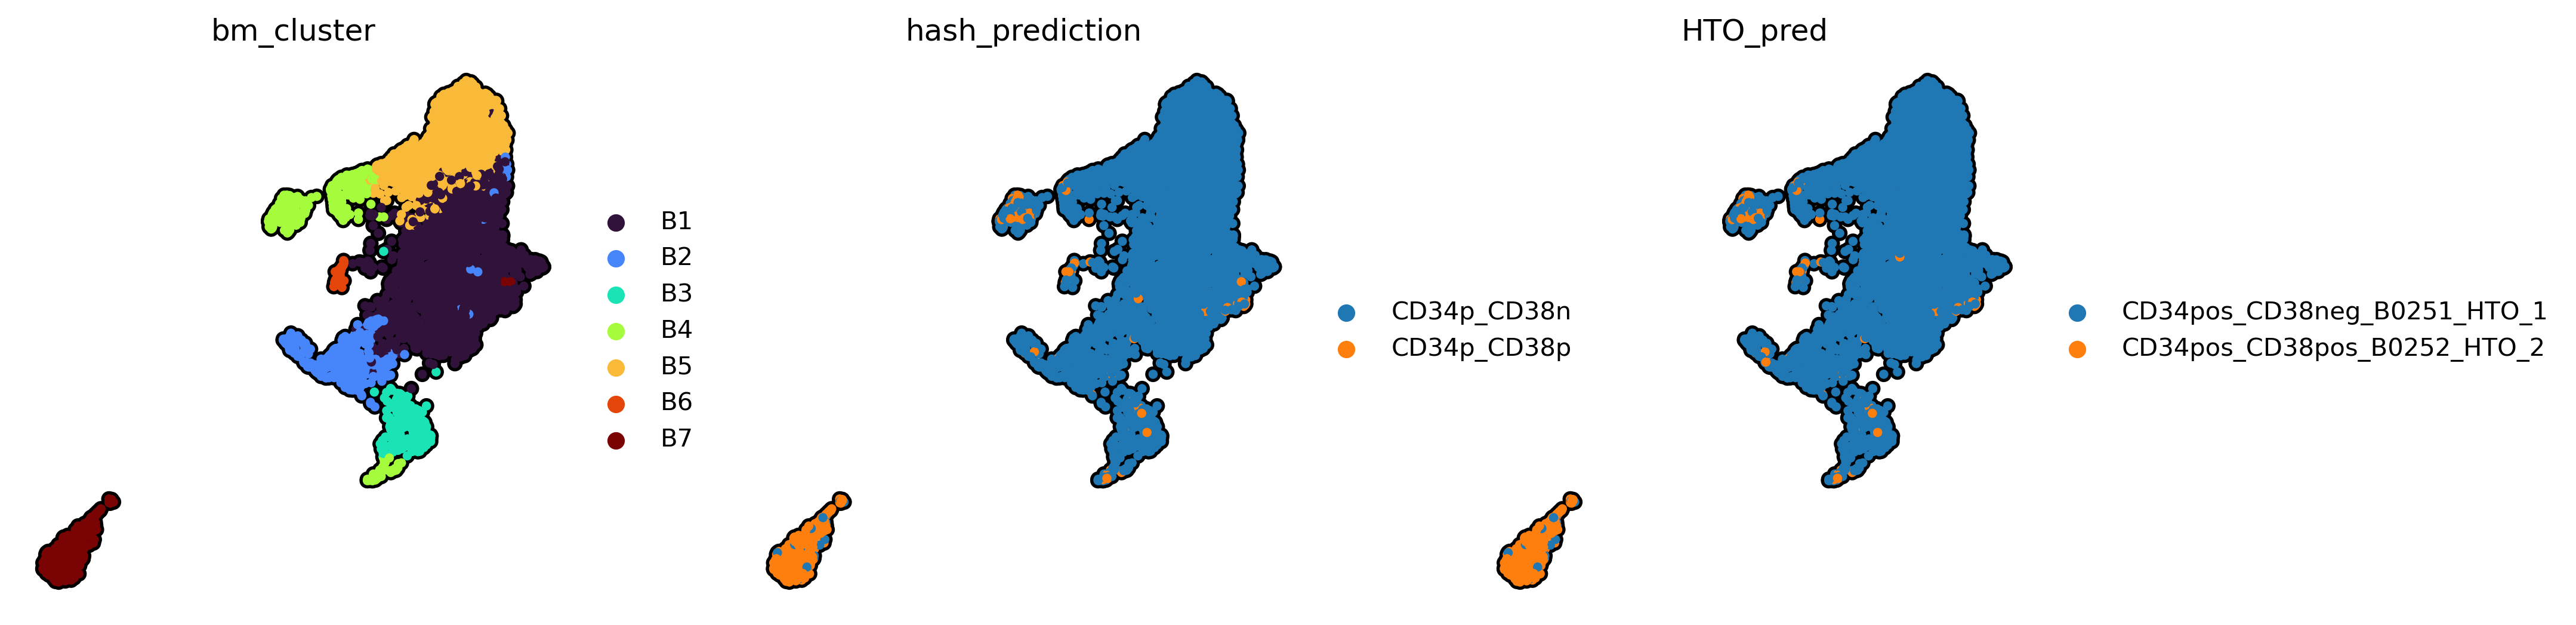

In [6]:
# selection variables
genes = ["bm_cluster", "hash_prediction", 'HTO_pred']

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=genes,
    size=55,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
)

In [7]:
fpath = "/scratch/indikar_root/indikar1/shared_data/bone_marrow_tsb_features/feature_barcodes/fbc_map.csv"
df = pd.read_csv(fpath)

df['cell_barcode'] = df['cell_barcode'] + "-1"
df = df.drop(columns='pred')
df = pd.melt(df, id_vars='cell_barcode')

df["variable"] = df["variable"].str.replace(r"^chunk_\d+_", "", regex=True)
df["variable"] = df["variable"] + "_ft"
features = list(df['variable'].unique())
print(features)

print(f"Total cells: {df['cell_barcode'].nunique()}")
print(f"Total reads: {df['value'].sum()}")
print(f"Mean reads/cell: {df['value'].sum() / df['cell_barcode'].nunique()}")

print(f"\n---- Total Reads by Hash Code  ----")
gx = df.groupby('variable')['value'].sum()
print(gx.to_string())

# sum over all chunks (by cell id)
df = df.groupby(['cell_barcode', 'variable'])['value'].sum().reset_index()
df = pd.pivot_table(df, index='cell_barcode', columns='variable', values='value', fill_value=0.0)

df = df.reindex(adata.obs_names) 

df.head()

['CD133_ft', 'CD34_ft', 'CD45RA_ft', 'CD49f_ft', 'CD90_ft']
Total cells: 6292
Total reads: 843865.0
Mean reads/cell: 134.11713286713288

---- Total Reads by Hash Code  ----
variable
CD133_ft      79043.0
CD34_ft      134922.0
CD45RA_ft    238220.0
CD49f_ft      24155.0
CD90_ft      367525.0


variable,CD133_ft,CD34_ft,CD45RA_ft,CD49f_ft,CD90_ft
AAACCAAAGGCGATCT-1,5.0,7.0,17.0,0.0,23.0
AAACCAAAGGTGAACG-1,5.0,6.0,10.0,3.0,24.0
AAACCATTCCCTGTCA-1,2.0,9.0,20.0,5.0,38.0
AAACCATTCCGCGATG-1,8.0,17.0,14.0,1.0,22.0
AAACCATTCCTGTCGC-1,7.0,3.0,7.0,1.0,20.0


In [8]:
adata.obs = adata.obs.join(df)    
adata.obs.head()

,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,SELL_mean,cell_labels,CD34p_CD38n,CD34p_CD38p,hash_prediction,CD133_ft,CD34_ft,CD45RA_ft,CD49f_ft,CD90_ft
AAACCAAAGGCGATCT-1,bone_marrow,7035,8.858795,44635.0,10.706296,34.950151,49.842052,57.302565,66.010978,1521.0,...,1.337802,MPP,53.0,3.0,CD34p_CD38n,5.0,7.0,17.0,0.0,23.0
AAACCAAAGGTGAACG-1,bone_marrow,4440,8.398635,21652.0,9.982900,37.091262,51.533346,59.763532,69.517827,639.0,...,0.186091,MEG/ERY,35.0,4.0,CD34p_CD38n,5.0,6.0,10.0,3.0,24.0
AAACCATTCCCTGTCA-1,bone_marrow,6370,8.759512,40379.0,10.606090,33.547141,47.425642,56.833998,66.601451,1230.0,...,1.247767,CMP,72.0,3.0,CD34p_CD38n,2.0,9.0,20.0,5.0,38.0
AAACCATTCCGCGATG-1,bone_marrow,3872,8.261785,15760.0,9.665294,37.912437,51.979695,59.904822,69.302030,545.0,...,1.327408,HSC,50.0,7.0,CD34p_CD38n,8.0,17.0,14.0,1.0,22.0
AAACCATTCCTGTCGC-1,bone_marrow,4817,8.480114,19367.0,9.871378,30.897919,43.754841,52.253834,62.621986,624.0,...,1.337802,MPP,37.0,4.0,CD34p_CD38n,7.0,3.0,7.0,1.0,20.0


In [13]:
adata.obs['CD45RA_ft'].mean()

37.45017857142857

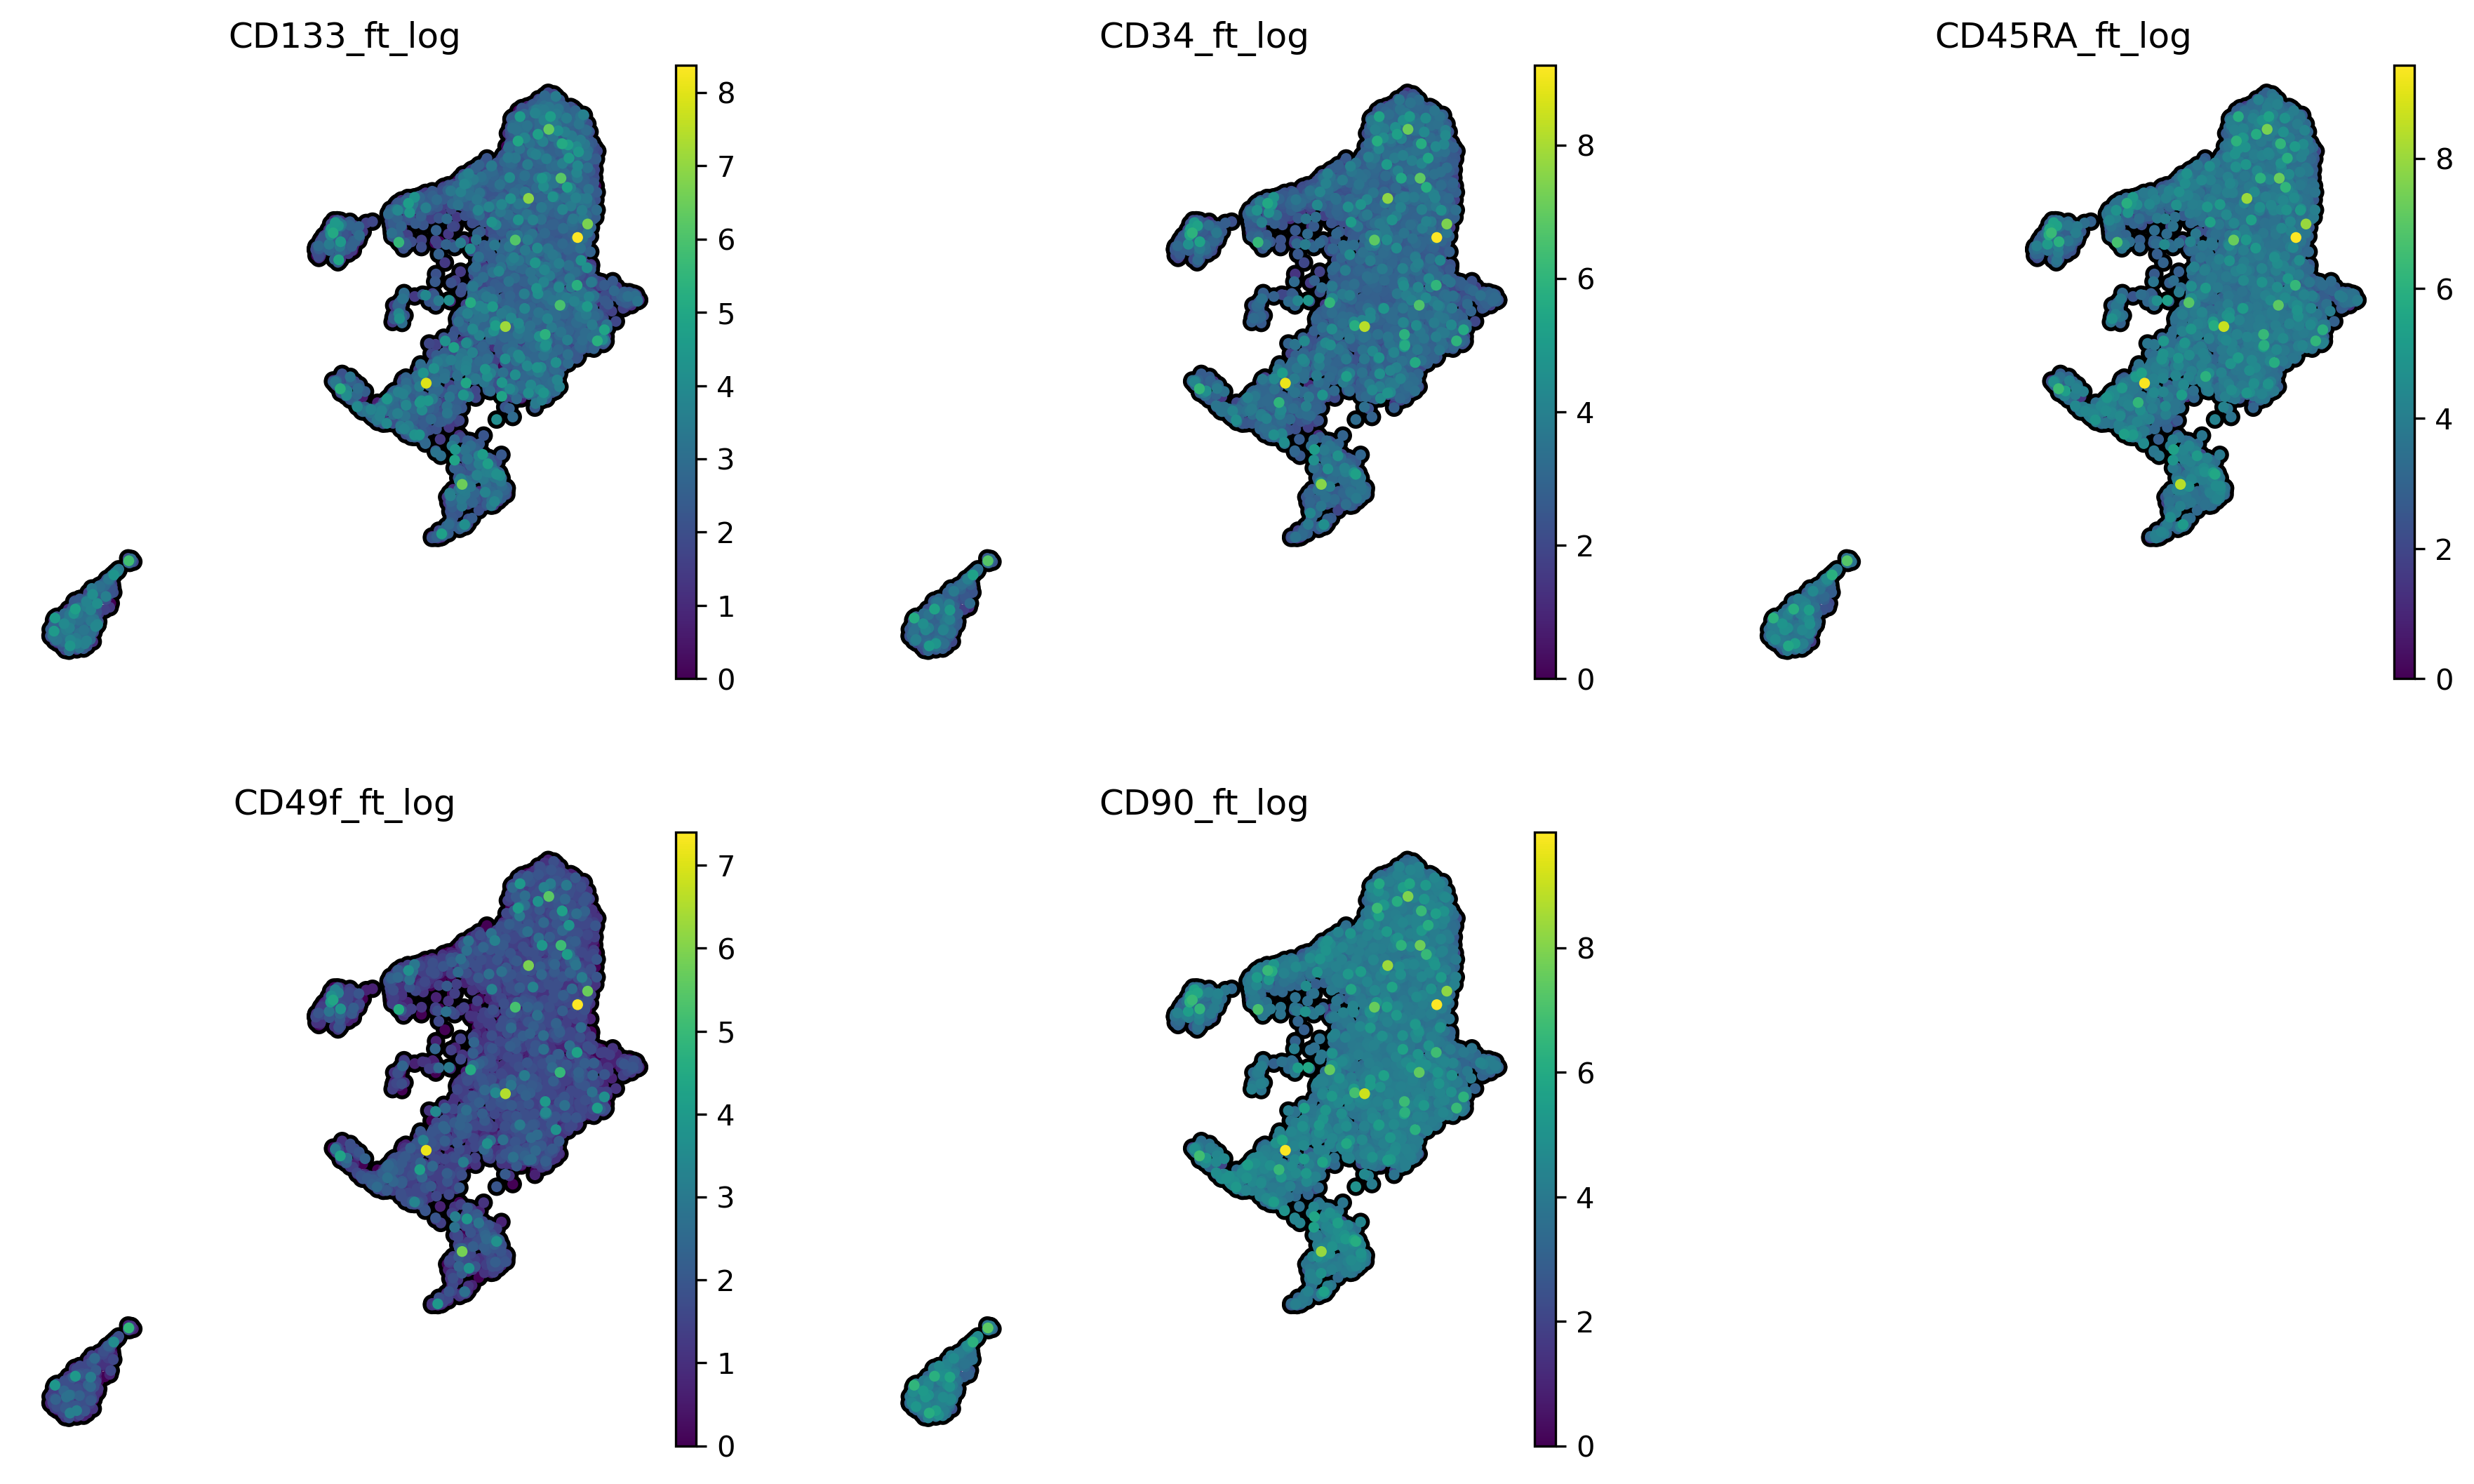

In [11]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

log_features = [f"{x}_log" for x in features]
adata.obs[log_features] = np.log1p(adata.obs[features])

sc.pl.umap(
    adata,
    color=log_features,
    size=55,
    ncols=3,
    alpha=1,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
)